# Exploratory Data Analysis (EDA)

## Objective

Explore the obesity-risk dataset to understand its numerical and categorical features, distributions, unusual values, and relationships with the seven obesity-risk categories.

The analysis helps identify patterns in the data and provides a clearer understanding of the features used for classification.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Loading the Dataset

Load the obesity-risk dataset and check its dimensions.

The dataset contains 20,758 records and 18 columns, including 16 predictive features, one target variable, and one record identifier.

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "obesity.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (20758, 18)


## Feature Groups

The dataset contains 16 predictive features: eight numerical and eight categorical.

**Numerical features** describe measurements and habits, including Age, Height, Weight, vegetable consumption (FCVC), number of main meals (NCP), water consumption (CH2O), physical activity (FAF), and technology use (TUE).

**Categorical features** describe characteristics and responses such as Gender, family history, eating habits, smoking, calorie monitoring, alcohol consumption, and transportation.

`NObeyesdad` is the obesity-risk category we want to understand. The `id` column only identifies records and is not a predictive feature.

In [3]:
identifier_column = "id"
target_column = "NObeyesdad"

numerical_features = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
]

categorical_features = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "CAEC",
    "SMOKE",
    "SCC",
    "CALC",
    "MTRANS",
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 8
Categorical features: 8


## Numerical Feature Distributions

Histograms show how frequently different numerical values occur. They help us understand where most records are concentrated and whether a feature has a wide or narrow range.

Boxplots summarize the middle value, spread, and possible outliers in each feature.

An outlier is a value noticeably different from most other records. It is not automatically an error and should not be removed without investigation.

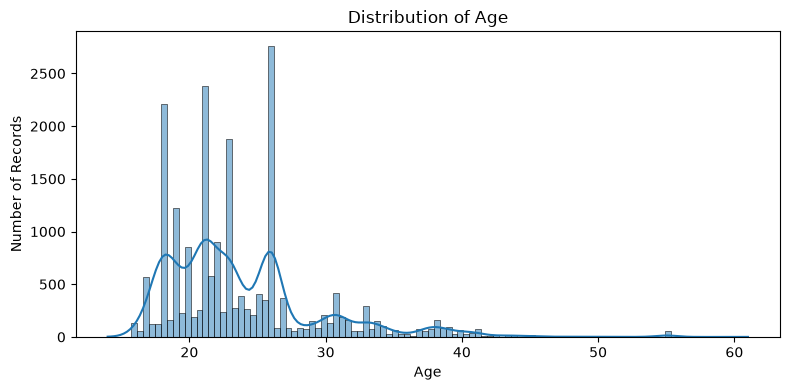

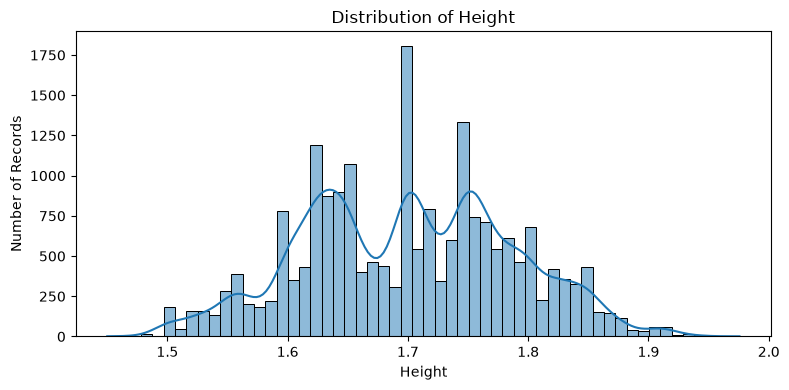

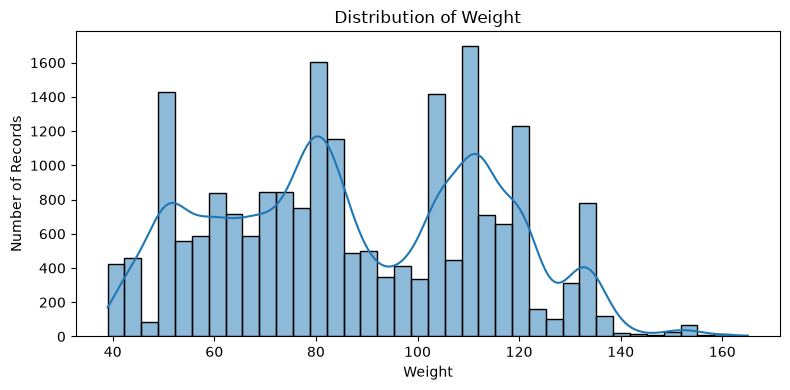

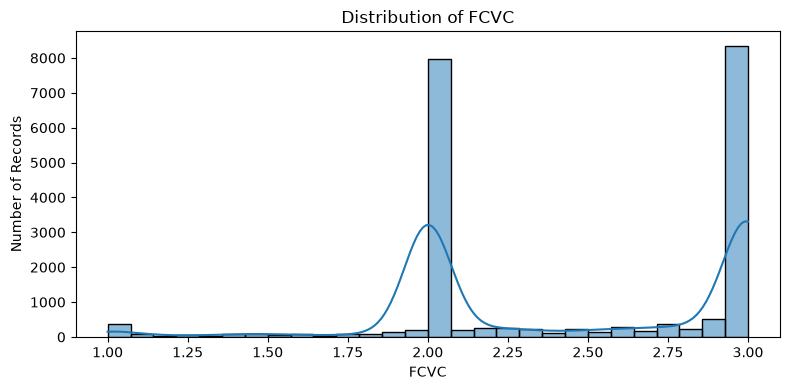

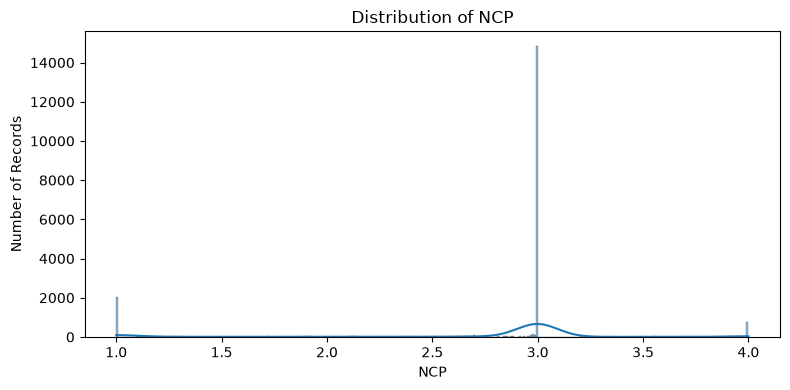

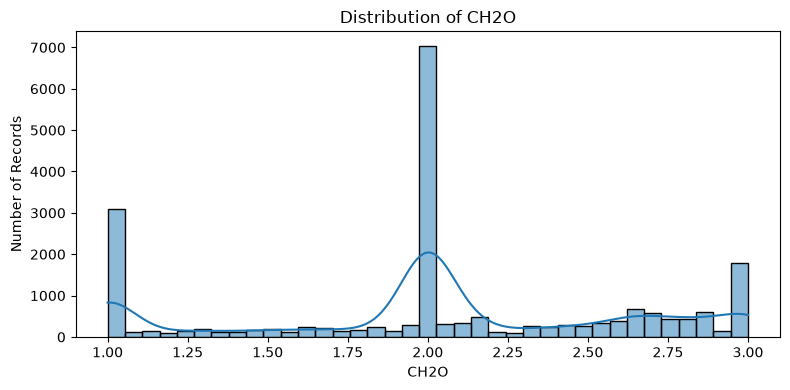

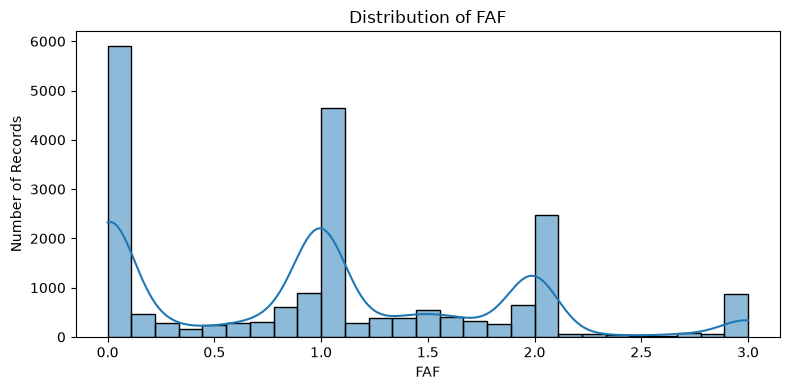

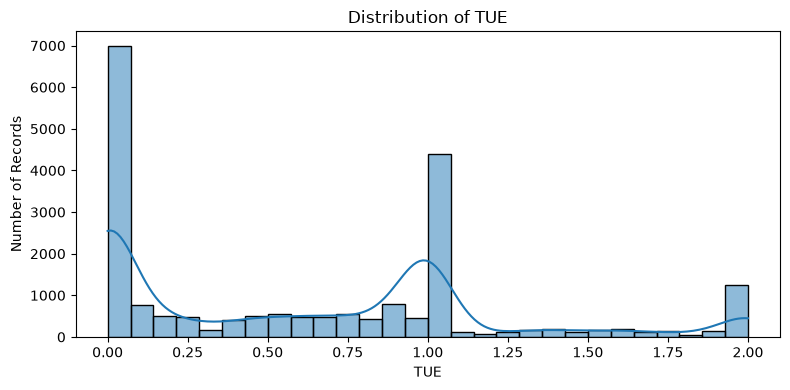

In [4]:
for column in numerical_features:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=column,
        kde=True,
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Records")
    plt.tight_layout()
    plt.show()

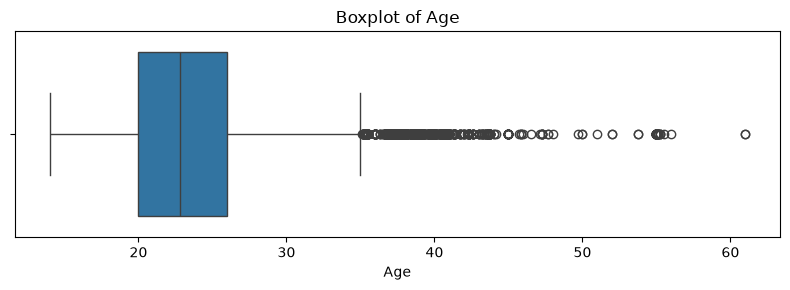

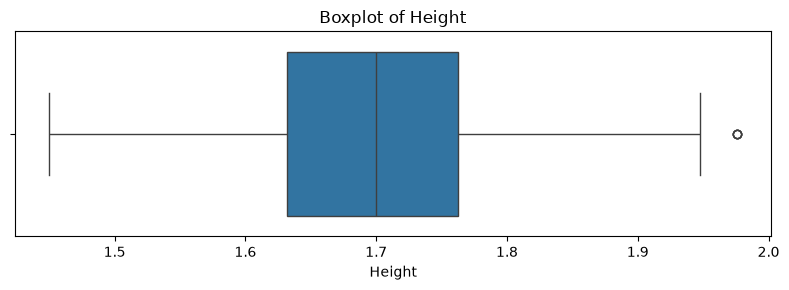

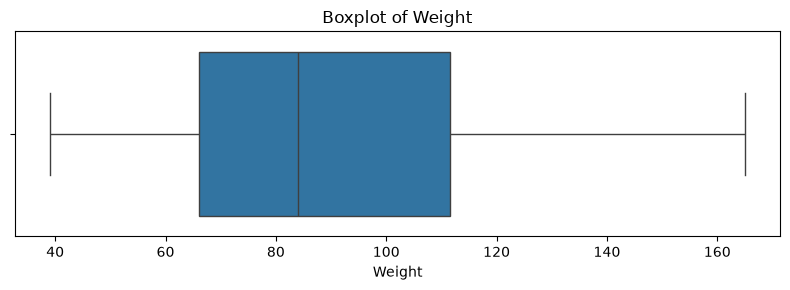

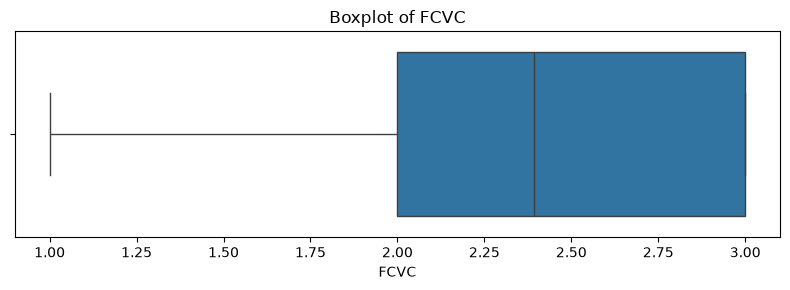

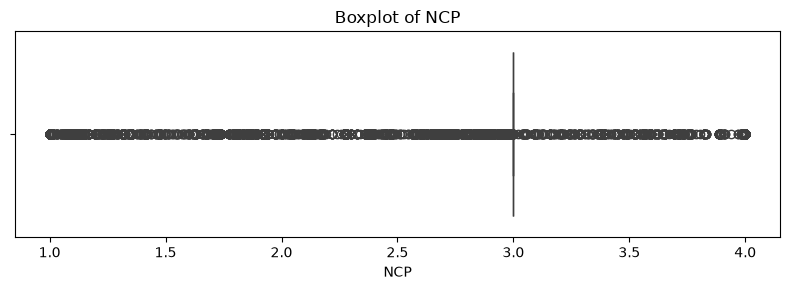

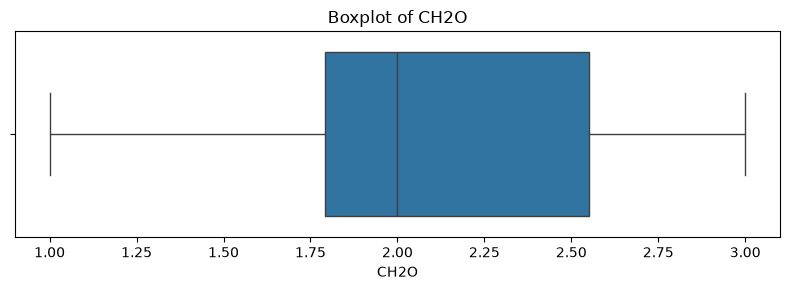

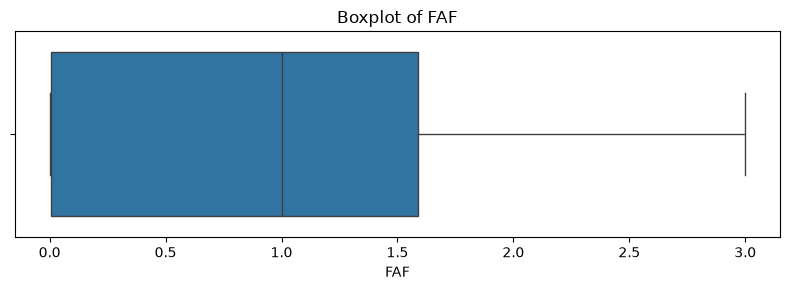

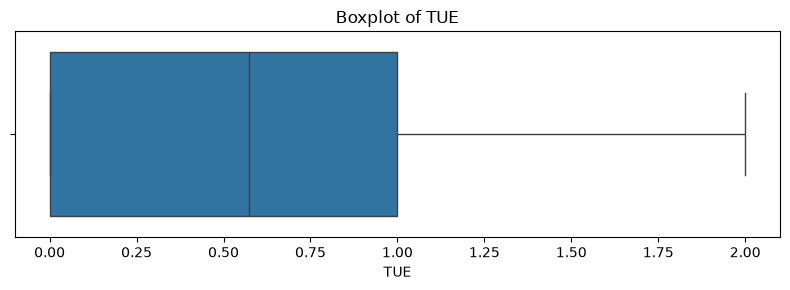

In [5]:
for column in numerical_features:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=df,
        x=column,
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

### Outlier Interpretation

The numerical boxplots help identify values that are unusually high or low compared with most records.

An outlier is not necessarily an incorrect value. For example, a person may have a higher Weight or Age than most individuals while still representing a valid observation.

The data-quality checks did not identify values outside the numerical ranges examined. Therefore, unusual values are retained rather than automatically removed.

The preprocessing pipeline handles missing values and feature scaling but does not remove or replace outliers.

This preserves the original dataset and avoids discarding potentially meaningful observations.

## Categorical Feature Distributions

Unlike numerical features, categorical features contain responses such as `yes`, `no`, or `Sometimes`.

Frequency tables show the number and percentage of records belonging to each response. Count plots display the same information visually.

This helps us understand which responses are common and which have fewer examples.

In [6]:
for column in categorical_features:
    category_counts = df[column].value_counts()
    category_percentages = (
        df[column]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    category_summary = pd.DataFrame({
        "Count": category_counts,
        "Percentage": category_percentages,
    })

    print(f"\n{column}")
    print("-" * len(column))
    display(category_summary)


Gender
------


,Count,Percentage
Gender,,
Female,10422,50.21
Male,10336,49.79



family_history_with_overweight
------------------------------


,Count,Percentage
family_history_with_overweight,,
yes,17014,81.96
no,3744,18.04



FAVC
----


...

,Count,Percentage
SCC,,
no,20071,96.69
yes,687,3.31



CALC
----


,Count,Percentage
CALC,,
Sometimes,15066,72.58
no,5163,24.87
Frequently,529,2.55



MTRANS
------


,Count,Percentage
MTRANS,,
Public_Transportation,16687,80.39
Automobile,3534,17.02
Walking,467,2.25
Motorbike,38,0.18
Bike,32,0.15


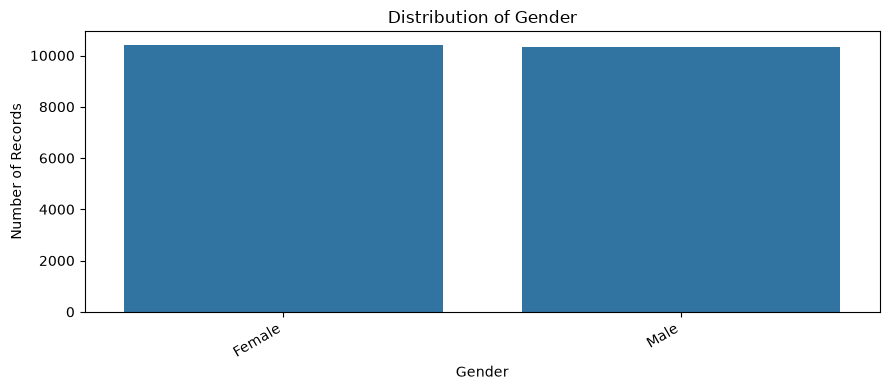

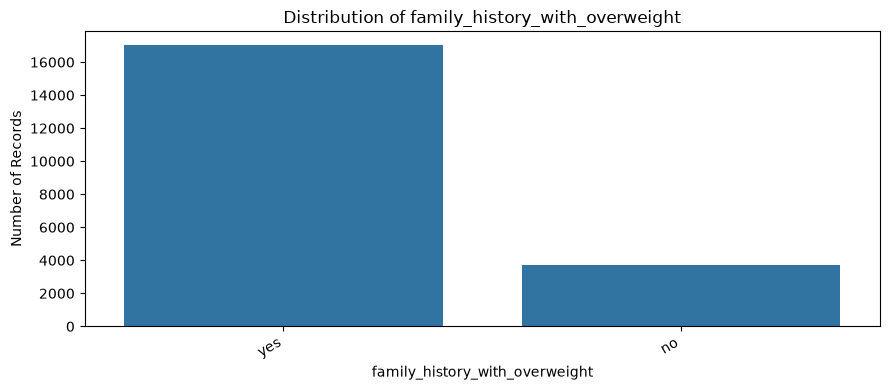

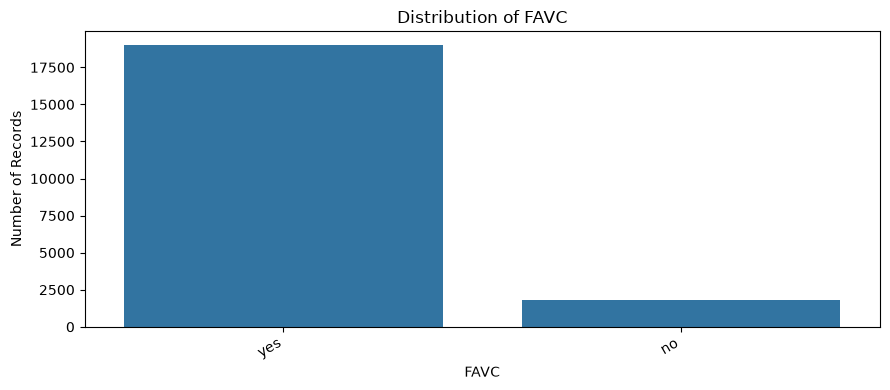

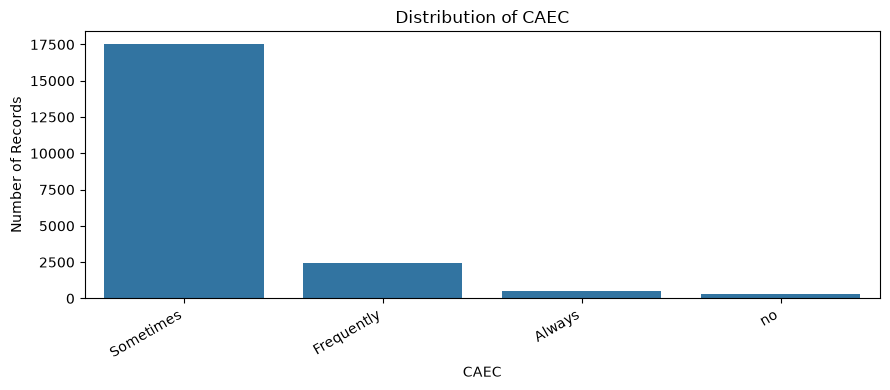

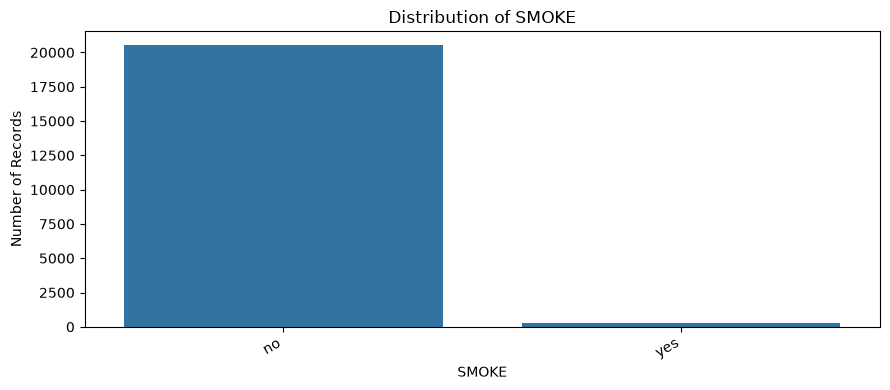

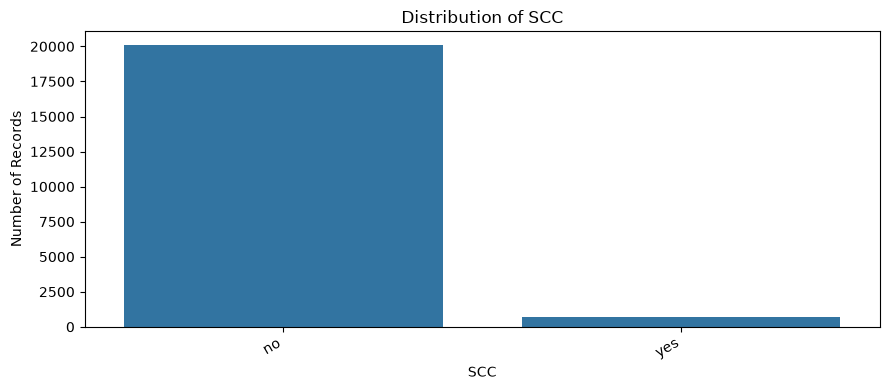

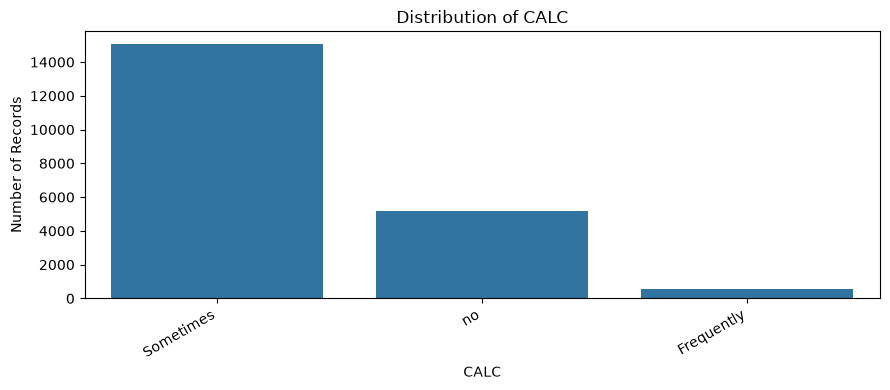

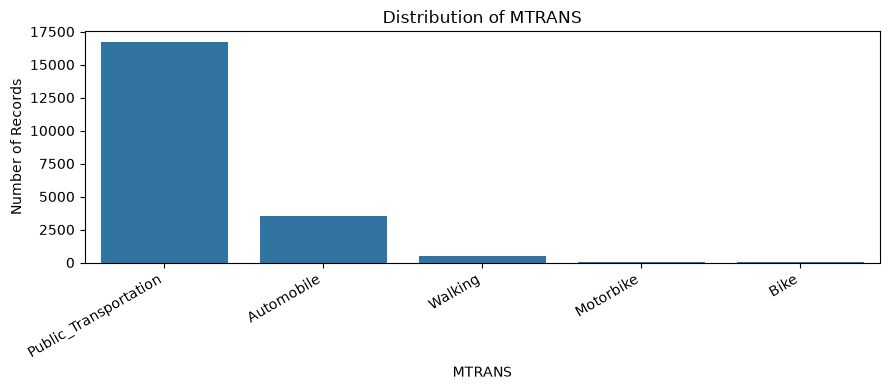

In [7]:
for column in categorical_features:
    category_order = df[column].value_counts().index

    plt.figure(figsize=(9, 4))

    sns.countplot(
        data=df,
        x=column,
        order=category_order,
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## Category Frequency Analysis

Identify the most common and least common response for each categorical feature.

Category concentration measures the percentage of records belonging to the most frequent response.

For example, approximately 98.82% of records have `SMOKE = no`. This means the dataset contains far fewer smoking records, so comparisons involving that smaller group should be interpreted carefully.

In [8]:
category_extremes = []

for column in categorical_features:
    counts = df[column].value_counts()

    category_extremes.append({
        "Feature": column,
        "Most common category": counts.idxmax(),
        "Most common count": counts.max(),
        "Least common category": counts.idxmin(),
        "Least common count": counts.min(),
    })

category_extremes_df = pd.DataFrame(category_extremes)

category_extremes_df

,Feature,Most common category,Most common count,Least common category,Least common count
0,Gender,Female,10422,Male,10336
1,family_history_with_overweight,yes,17014,no,3744
2,FAVC,yes,18982,no,1776
3,CAEC,Sometimes,17529,no,279
4,SMOKE,no,20513,yes,245
5,SCC,no,20071,yes,687
6,CALC,Sometimes,15066,Frequently,529
7,MTRANS,Public_Transportation,16687,Bike,32


In [9]:
category_concentration = []

for column in categorical_features:
    most_common_percentage = (
        df[column]
        .value_counts(normalize=True)
        .max()
        * 100
    )

    category_concentration.append({
        "Feature": column,
        "Largest category percentage": round(
            most_common_percentage,
            2,
        ),
    })

category_concentration_df = pd.DataFrame(
    category_concentration
).sort_values(
    by="Largest category percentage",
    ascending=False,
)

category_concentration_df

,Feature,Largest category percentage
4,SMOKE,98.82
5,SCC,96.69
2,FAVC,91.44
3,CAEC,84.44
1,family_history_with_overweight,81.96
7,MTRANS,80.39
6,CALC,72.58
0,Gender,50.21


## Target Class Distribution

Examine how many records belong to each of the seven obesity-risk categories.

The chart displays the classes from most to least frequent, making differences in class sizes easier to understand.

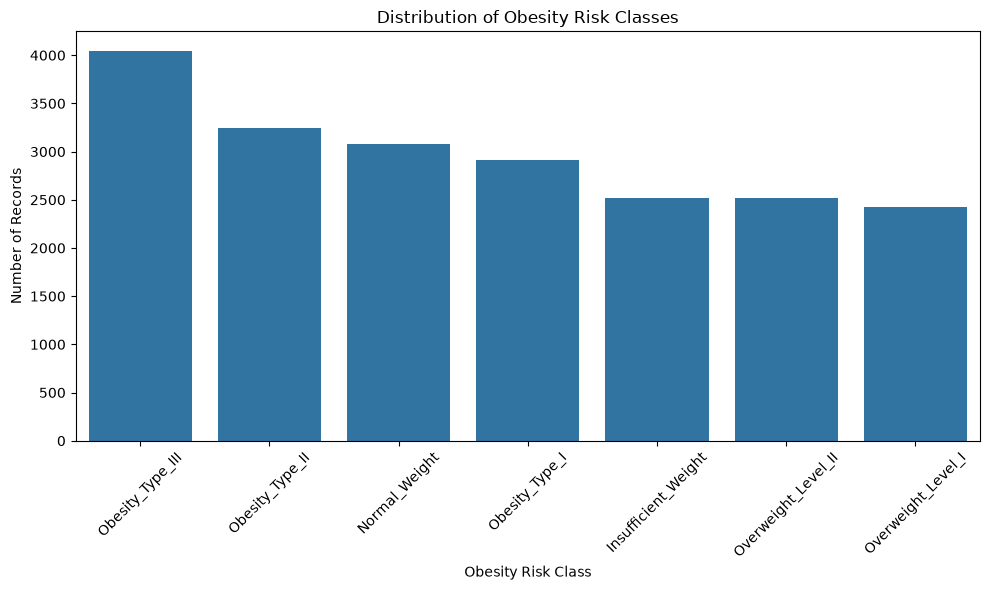

In [10]:
# Target class distribution

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x=target_column,
    order=df[target_column].value_counts().index
)

plt.title("Distribution of Obesity Risk Classes")
plt.xlabel("Obesity Risk Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Numerical Features by Obesity Risk Class

The earlier charts examined numerical features across the entire dataset. Here, we compare them separately for each obesity-risk category.

The classes are arranged from Insufficient Weight to Obesity Type III to make their differences easier to follow.

Boxplots show how values vary within each class. The median table provides a typical value for each feature and class.

The median is the middle value when observations are arranged in order. It is often easier to interpret than the mean when unusually high or low values are present.

In [11]:
class_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

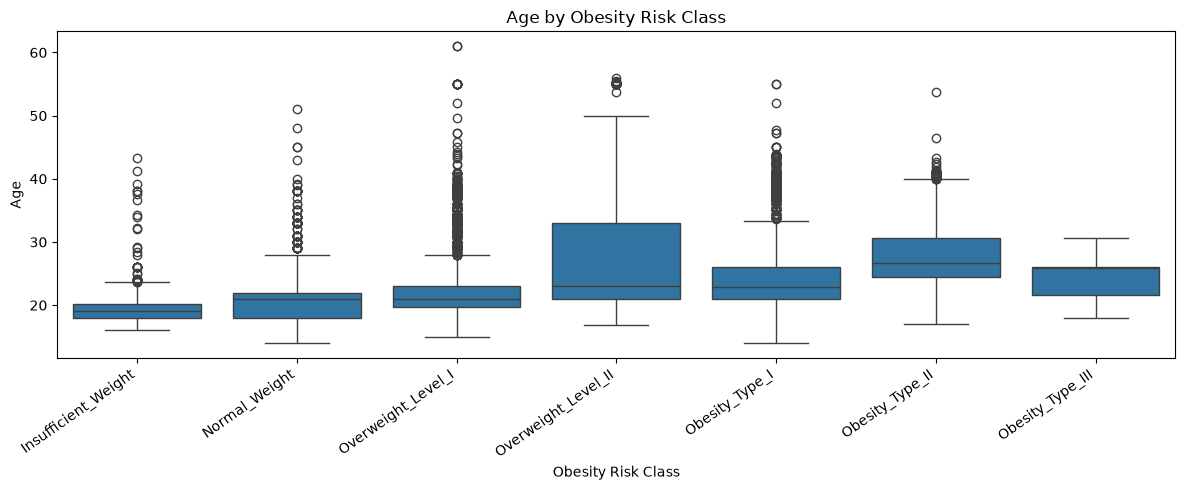

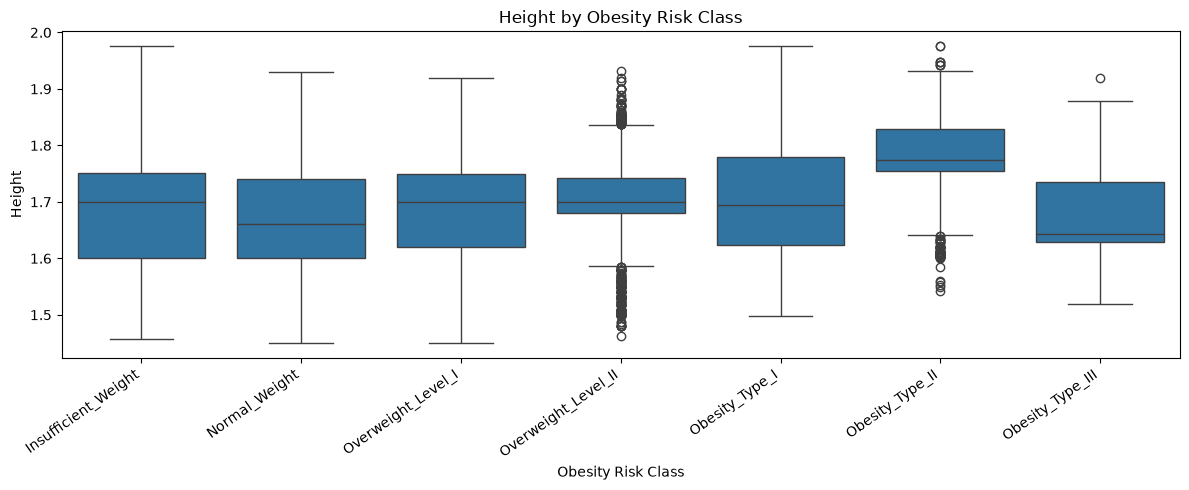

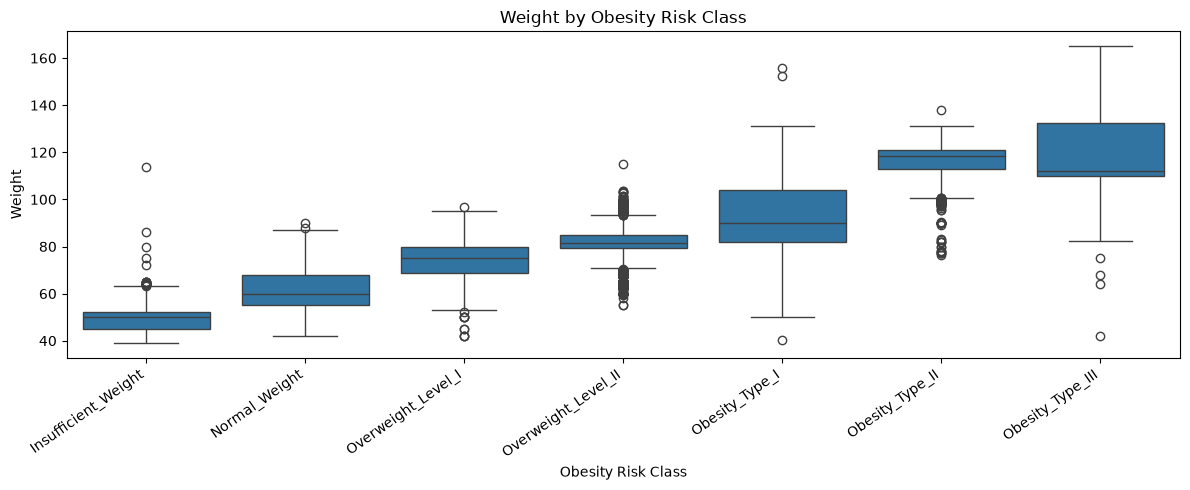

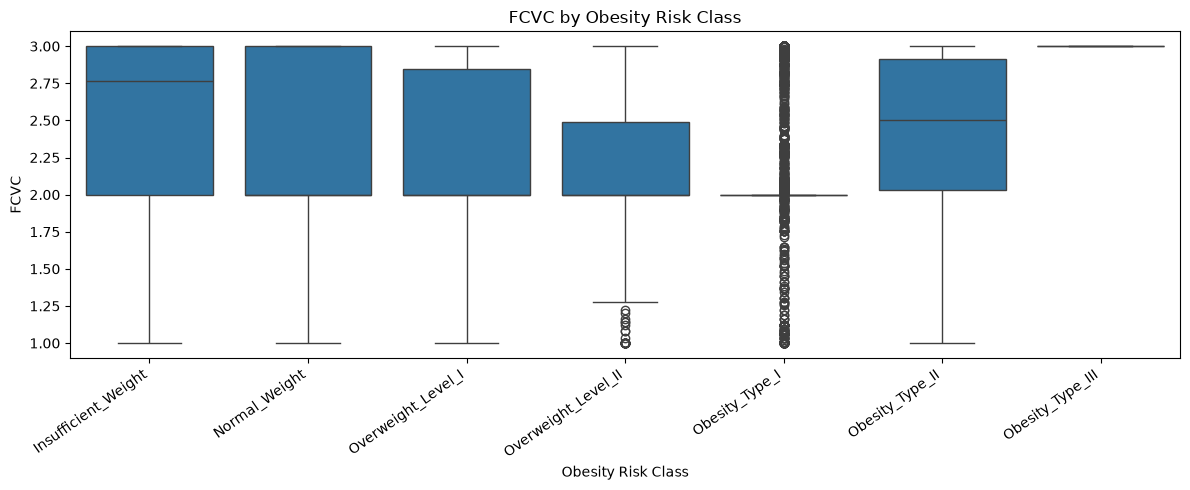

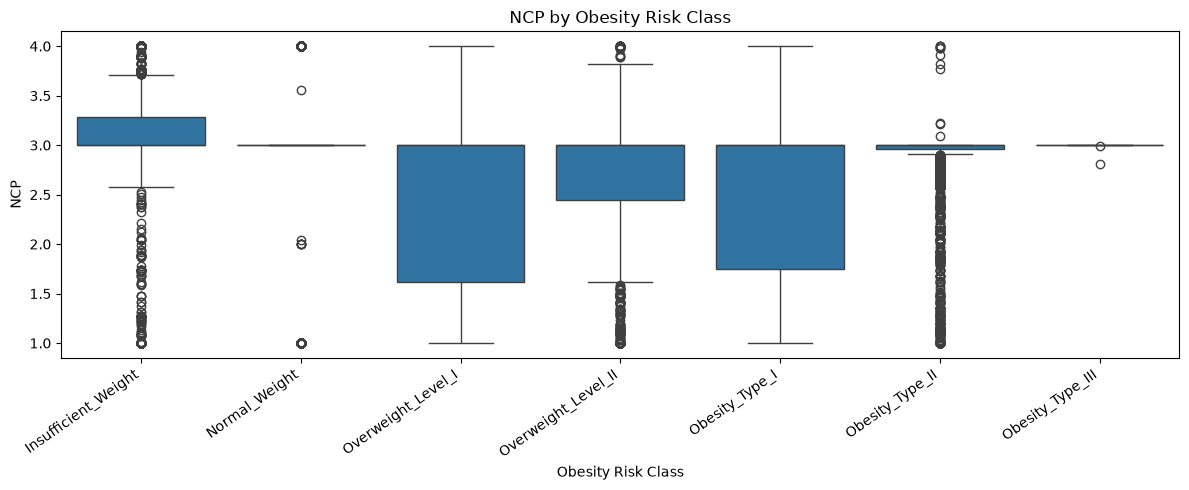

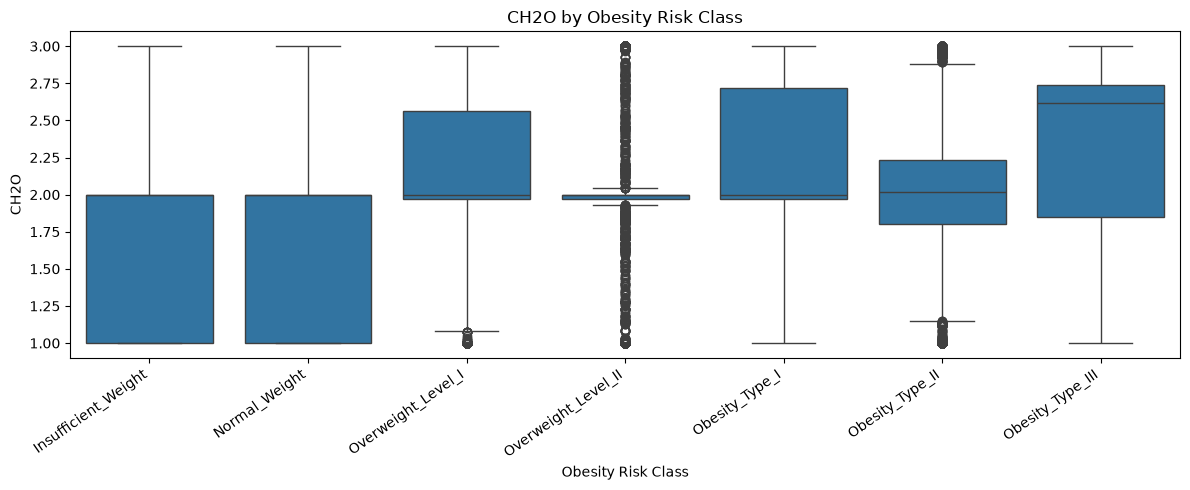

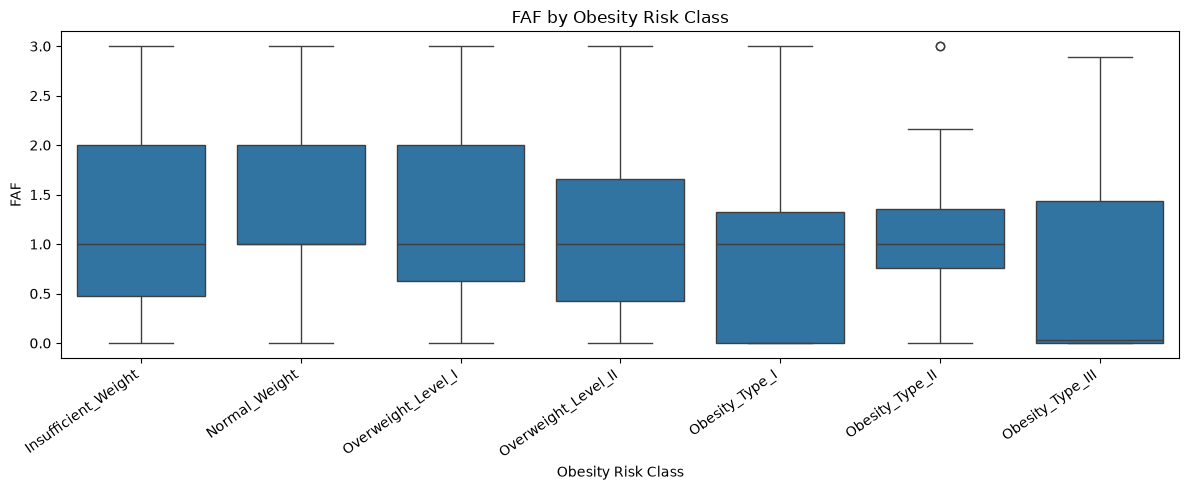

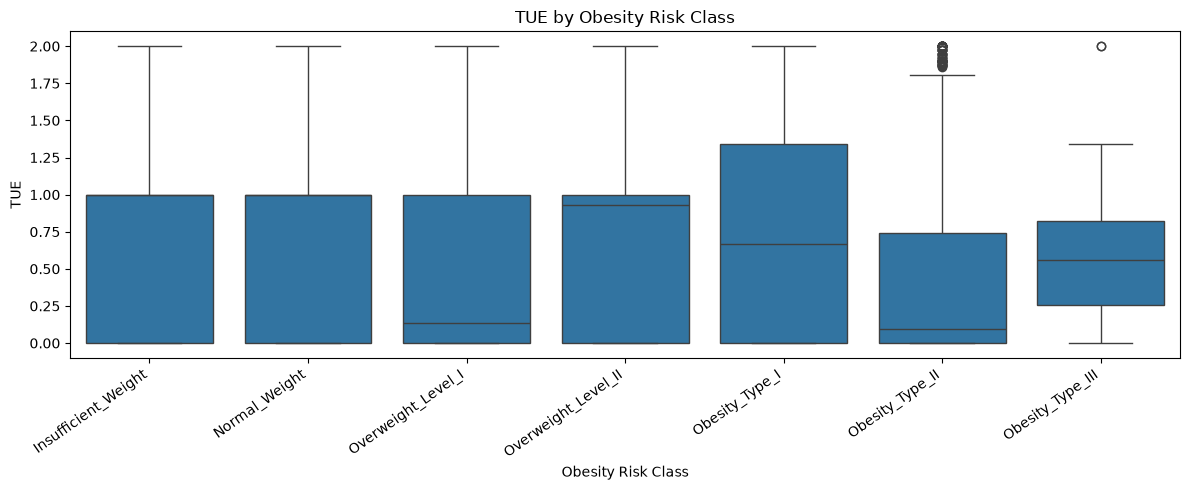

In [12]:
for column in numerical_features:
    plt.figure(figsize=(12, 5))

    sns.boxplot(
        data=df,
        x=target_column,
        y=column,
        order=class_order,
    )

    plt.title(f"{column} by Obesity Risk Class")
    plt.xlabel("Obesity Risk Class")
    plt.ylabel(column)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

In [13]:
numerical_class_medians = (
    df.groupby(target_column)[numerical_features]
    .median()
    .reindex(class_order)
    .round(2)
)

numerical_class_medians

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
NObeyesdad,,,,,,,,
Insufficient_Weight,19.00,1.70,50.00,2.77,3.0,2.00,1.00,1.00
Normal_Weight,21.00,1.66,60.00,2.00,3.0,2.00,1.00,1.00
Overweight_Level_I,21.00,1.70,75.00,2.00,3.0,2.00,1.00,0.13
Overweight_Level_II,23.00,1.70,81.63,2.00,3.0,2.00,1.00,0.93
Obesity_Type_I,22.85,1.69,90.12,2.00,3.0,2.00,1.00,0.67
Obesity_Type_II,26.70,1.77,118.33,2.50,3.0,2.01,1.00,0.09
Obesity_Type_III,25.96,1.64,111.91,3.00,3.0,2.62,0.04,0.56


## Categorical Features by Obesity Risk Class

This section examines how obesity-risk categories differ across categorical responses.

For each response, the percentage table shows how its records are distributed among the seven obesity-risk classes.

For example, the `Gender` table compares the obesity-risk distribution within Female records and within Male records.

Each response row totals approximately 100%. The heatmaps visualize these percentages to make differences between groups easier to identify.

These patterns show associations in the dataset, not cause-and-effect relationships.

In [14]:
for column in categorical_features:
    percentage_table = (
        pd.crosstab(
            df[column],
            df[target_column],
            normalize="index",
        )
        .mul(100)
        .reindex(columns=class_order)
        .round(1)
    )

    print(f"\n{column}")
    display(percentage_table)


Gender


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
Gender,,,,,,,
Female,15.6,15.9,10.3,7.2,12.2,0.1,38.8
Male,8.7,13.8,13.1,17.1,15.9,31.3,0.0



family_history_with_overweight


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
family_history_with_overweight,,,,,,,
no,38.7,34.5,20.2,5.2,1.3,0.1,0.0
yes,6.3,10.5,9.8,13.7,16.8,19.1,23.8



FAVC


...

NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
SCC,,,,,,,
no,11.4,14.6,10.9,12.4,14.4,16.2,20.2
yes,33.8,23.3,36.2,3.5,2.6,0.6,0.0



CALC


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
CALC,,,,,,,
Frequently,2.6,12.9,24.6,43.1,14.4,2.5,0.0
Sometimes,10.8,12.9,13.0,8.5,9.6,18.4,26.9
no,17.2,20.8,6.5,19.7,26.9,8.9,0.0



MTRANS


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
MTRANS,,,,,,,
Automobile,7.8,8.7,13.4,22.1,21.1,26.7,0.0
Bike,6.2,43.8,28.1,12.5,6.2,3.1,0.0
Motorbike,10.5,44.7,18.4,7.9,10.5,7.9,0.0
Public_Transportation,13.0,15.4,11.0,9.9,12.8,13.7,24.2
Walking,15.8,37.9,21.6,18.0,5.4,1.3,0.0


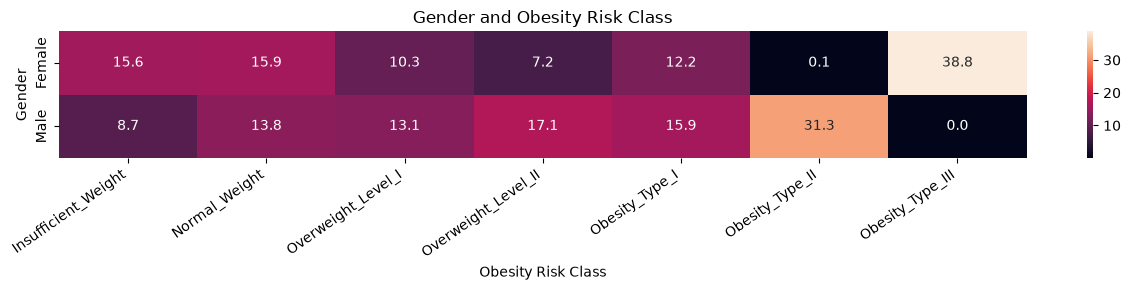

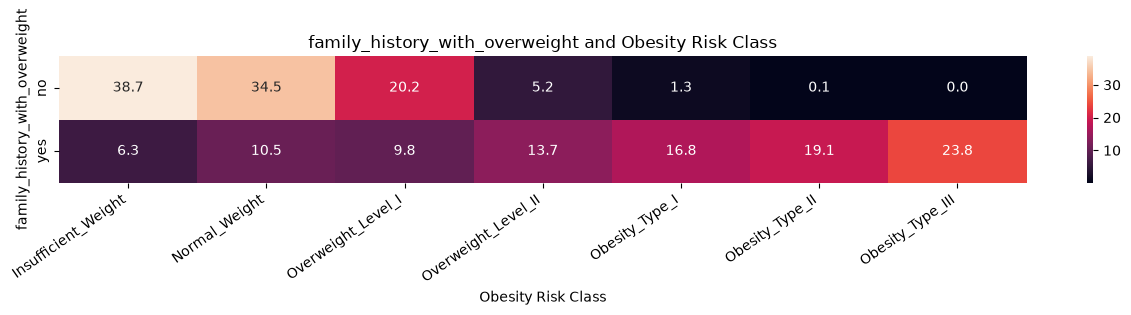

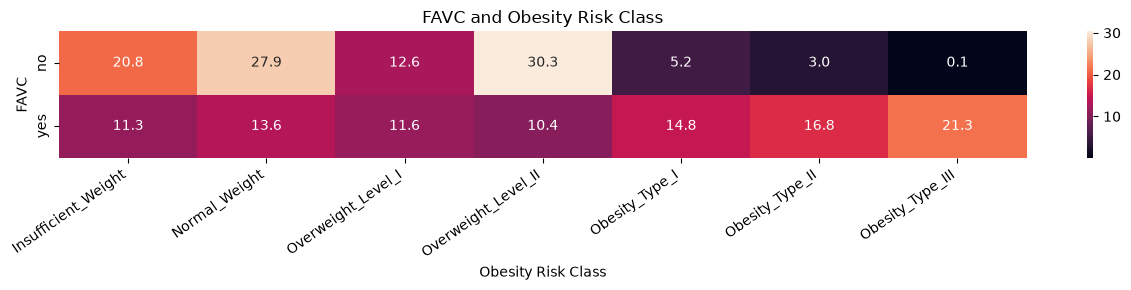

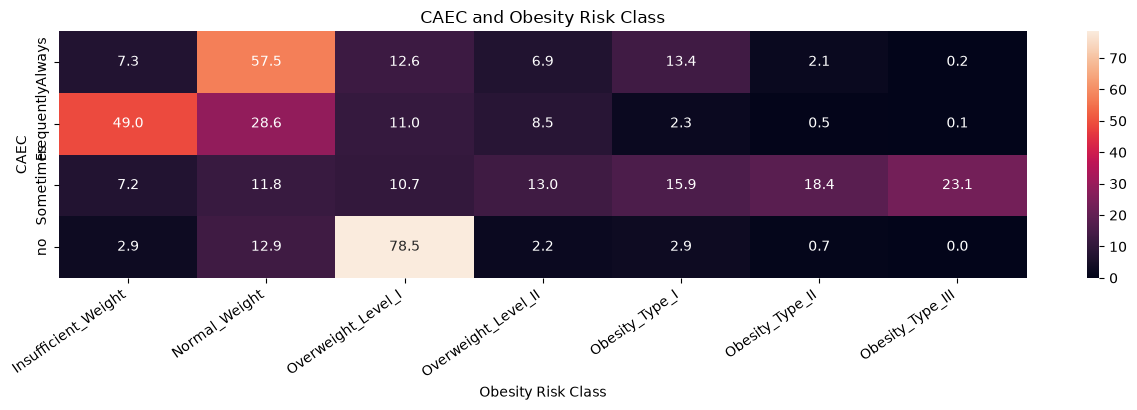

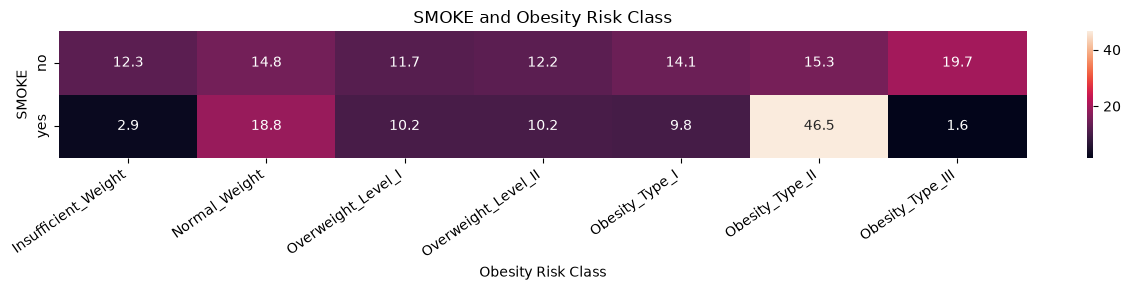

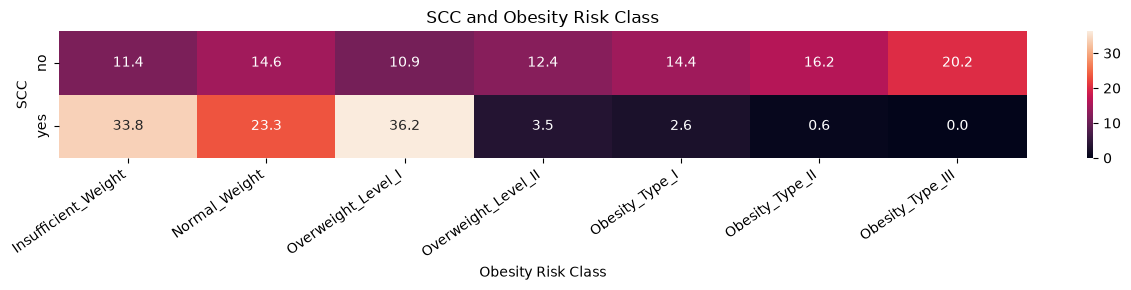

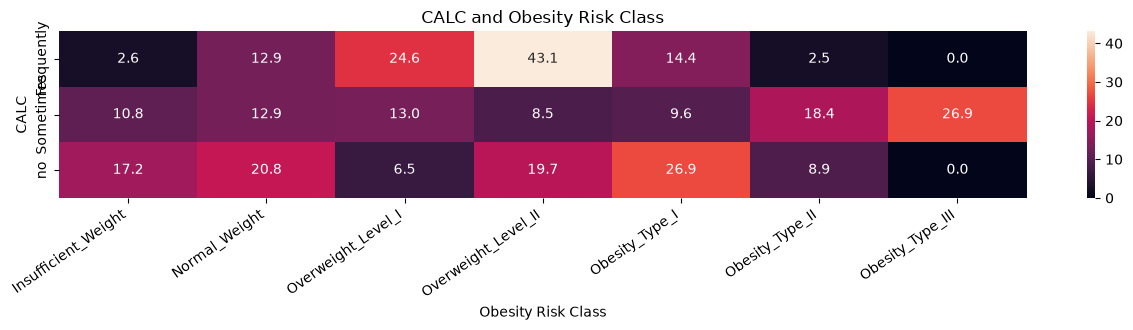

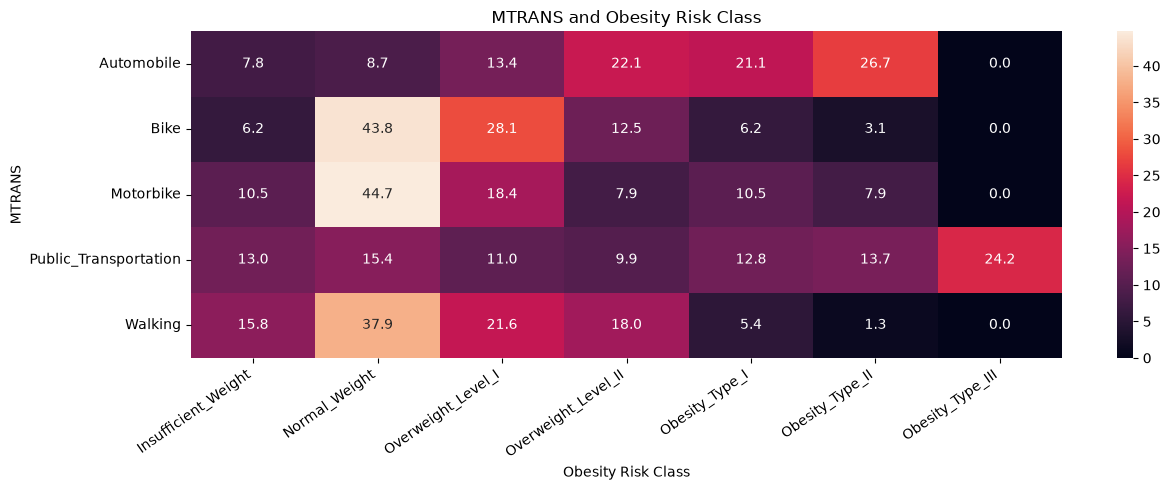

In [15]:
for column in categorical_features:
    percentage_table = (
        pd.crosstab(
            df[column],
            df[target_column],
            normalize="index",
        )
        .mul(100)
        .reindex(columns=class_order)
    )

    chart_height = max(3, len(percentage_table) * 0.8 + 1)

    plt.figure(figsize=(13, chart_height))

    sns.heatmap(
        percentage_table,
        annot=True,
        fmt=".1f",
    )

    plt.title(f"{column} and Obesity Risk Class")
    plt.xlabel("Obesity Risk Class")
    plt.ylabel(column)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

## Body Mass Index (BMI) Exploration

Body Mass Index (BMI) is a measurement that relates a person's weight to their height.

It is calculated using:

**BMI = Weight (kg) / Height (m)²**

BMI helps us examine weight relative to height rather than looking at Weight alone.

The original dataset contains Height and Weight but does not contain BMI as a separate column. We calculate it in a copy of the dataset for exploratory analysis.

BMI is not added to the original 16 predictive features in this notebook.

In [16]:
eda_df = df.copy()

eda_df["BMI"] = (
    eda_df["Weight"]
    / eda_df["Height"].pow(2)
)

eda_df["BMI"].describe().round(2)

count    20758.00
mean        30.24
std          8.33
min         12.87
25%         24.09
50%         29.38
75%         37.01
max         55.00
Name: BMI, dtype: float64

### Overall BMI Distribution

The BMI summary shows the mean, median, minimum, maximum, and spread of calculated BMI values.

The following histogram shows how BMI values are distributed across all records.

It helps us identify the range where most records are concentrated and whether some BMI values are unusually high or low.

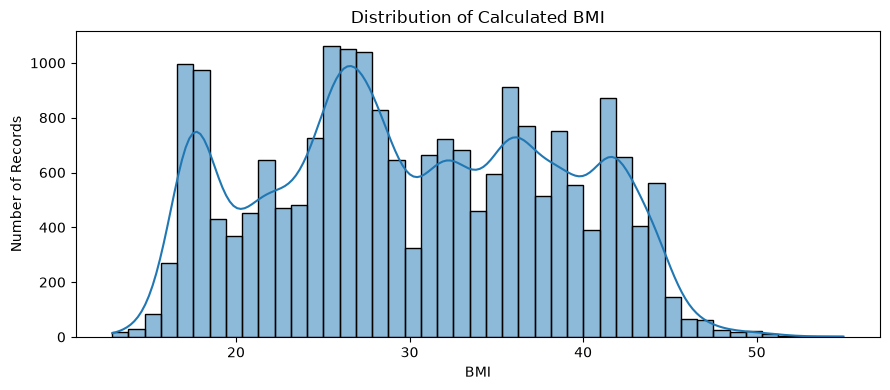

In [17]:
plt.figure(figsize=(9, 4))

sns.histplot(
    data=eda_df,
    x="BMI",
    kde=True,
)

plt.title("Distribution of Calculated BMI")
plt.xlabel("BMI")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### BMI Across Obesity-Risk Categories

Compare calculated BMI values separately for the seven obesity-risk categories.

The boxplot shows each class's middle BMI value, spread, and possible outliers.

This helps us examine whether BMI generally increases from lower to higher obesity-risk categories and how much the BMI values of different classes overlap.

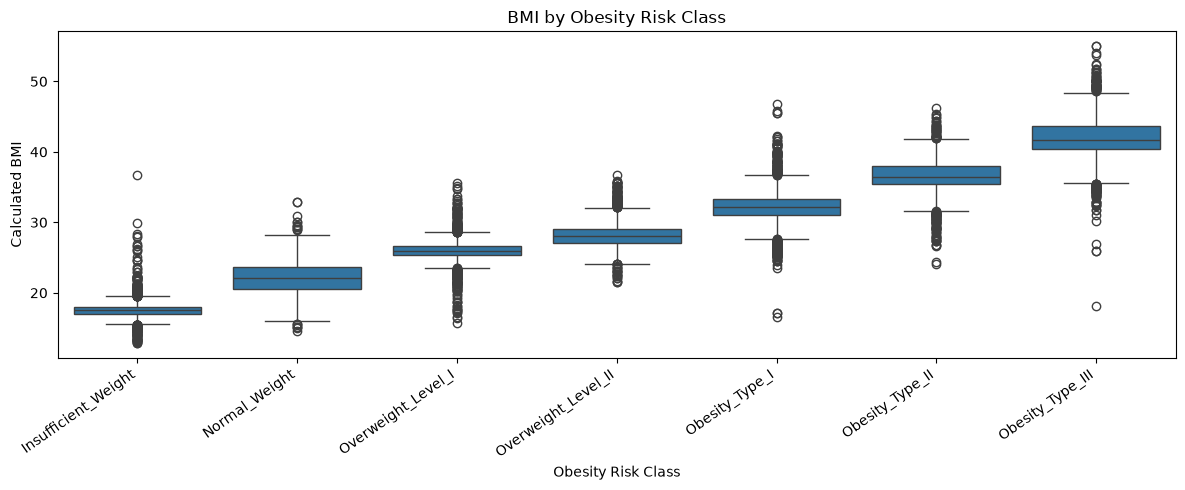

In [18]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=eda_df,
    x=target_column,
    y="BMI",
    order=class_order,
)

plt.title("BMI by Obesity Risk Class")
plt.xlabel("Obesity Risk Class")
plt.ylabel("Calculated BMI")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### BMI Summary by Class

Summarize BMI separately for each obesity-risk category using:

- **Count:** Number of records in the class.
- **Mean:** Average BMI.
- **Median:** Middle BMI value.
- **Min and Max:** Lowest and highest BMI values.

The median values make it easier to compare typical BMI across classes.

These results describe patterns in the provided dataset. BMI alone is not a complete assessment of a person's health.

In [19]:
bmi_class_summary = (
    eda_df.groupby(target_column)["BMI"]
    .agg(["count", "mean", "median", "min", "max"])
    .reindex(class_order)
    .round(2)
)

bmi_class_summary

,count,mean,median,min,max
NObeyesdad,,,,,
Insufficient_Weight,2523,17.58,17.51,12.87,36.78
Normal_Weight,3082,22.00,22.04,14.63,32.88
Overweight_Level_I,2427,26.06,25.96,15.76,35.56
Overweight_Level_II,2522,28.19,28.02,21.51,36.74
Obesity_Type_I,2910,32.15,32.12,16.60,46.81
Obesity_Type_II,3248,36.52,36.38,24.05,46.22
Obesity_Type_III,4046,41.78,41.75,18.18,55.00


## Height and Weight Relationship

Visualize Height and Weight together, using colors to represent the seven obesity-risk categories.

This helps identify patterns in physical measurements and how the obesity-risk classes are distributed.

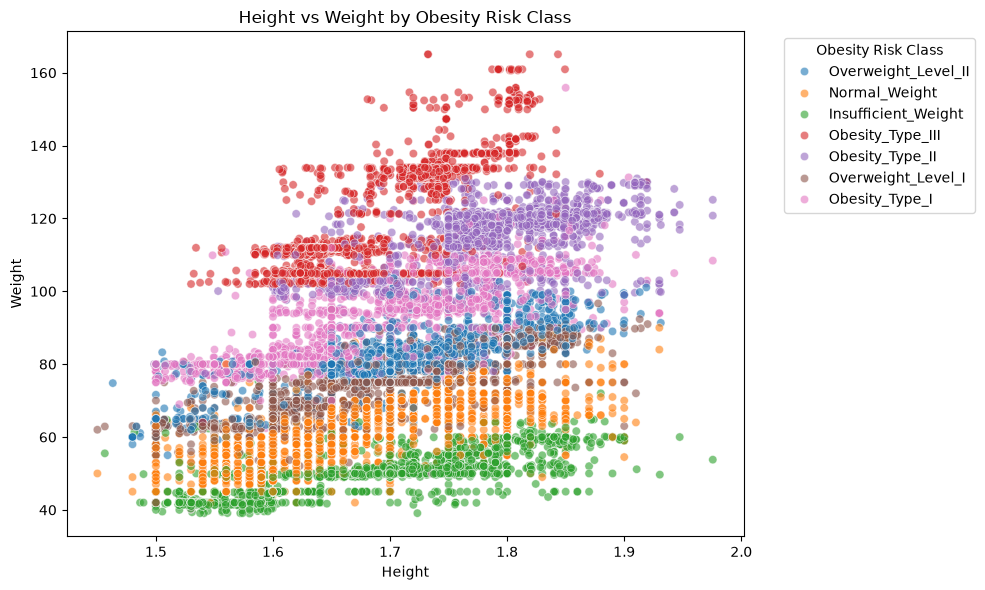

In [20]:
# Height vs Weight relationship
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Height",
    y="Weight",
    hue=target_column,
    alpha=0.6
)

plt.title("Height vs Weight by Obesity Risk Class")
plt.xlabel("Height")
plt.ylabel("Weight")

plt.legend(
    title="Obesity Risk Class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Pearson Correlation Analysis

Correlation measures how two variables change in relation to each other.

Pearson correlation examines linear relationships between numerical features. Its values range from -1 to +1:

- **Near +1:** Strong positive relationship; both variables tend to increase together.
- **Near -1:** Strong negative relationship; one tends to decrease as the other increases.
- **Near 0:** Little or no linear relationship.

The heatmap compares the eight original numerical features and helps identify relationships such as Height and Weight.

Correlation does not prove that one variable causes changes in another.

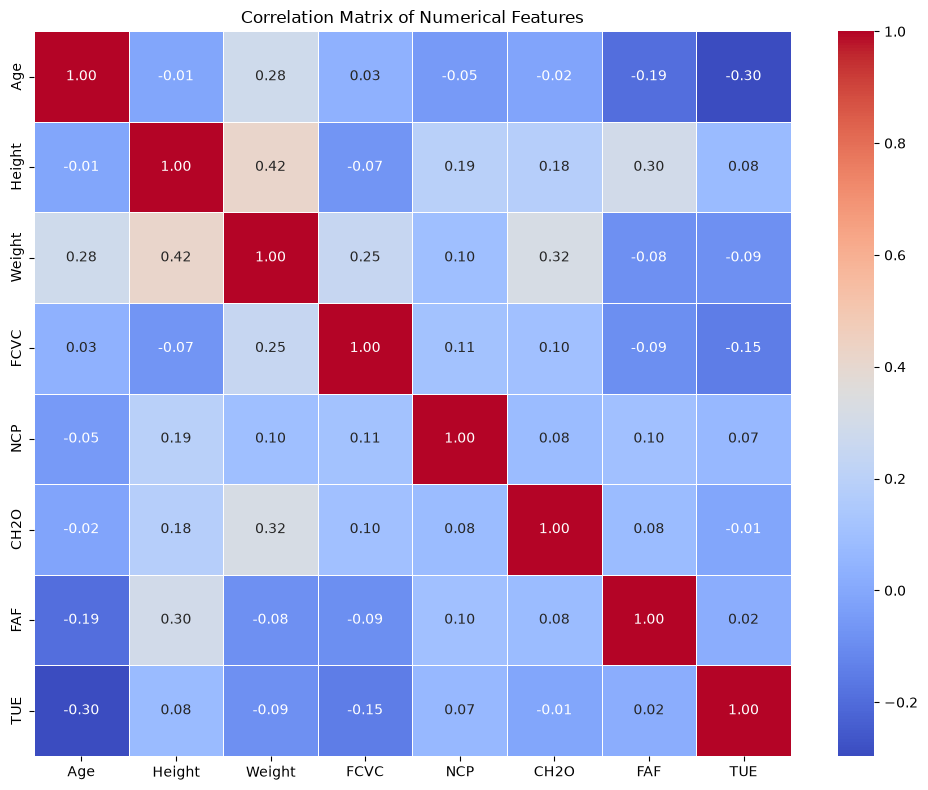

In [21]:
# Correlation analysis
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

## Spearman Correlation Analysis

Spearman correlation examines whether two variables generally increase or decrease together, even when their relationship is not linear.

The obesity-risk categories have a meaningful order, from Insufficient Weight to Obesity Type III.

We first represent these categories using numbers from 0 to 6 so their order can be included in the correlation analysis.

These numbers represent class order only. They do not replace the original target labels or change the classification problem.

In [22]:
target_mapping = {
    class_name: class_number
    for class_number, class_name in enumerate(class_order)
}

eda_df["Target_Order"] = (
    eda_df[target_column]
    .map(target_mapping)
)

eda_df[
    [target_column, "Target_Order"]
].drop_duplicates().sort_values("Target_Order")

,NObeyesdad,Target_Order
2,Insufficient_Weight,0
1,Normal_Weight,1
8,Overweight_Level_I,2
0,Overweight_Level_II,3
12,Obesity_Type_I,4
6,Obesity_Type_II,5
3,Obesity_Type_III,6


### Correlation With Ordered Obesity-Risk Categories

Calculate Spearman correlation using the eight numerical features, calculated BMI, and ordered obesity-risk categories.

A positive correlation with `Target_Order` means that higher feature values tend to appear with higher obesity-risk categories.

A negative correlation means that higher feature values tend to appear with lower obesity-risk categories.

The correlation matrix and heatmap help us compare these relationships.

In [23]:
correlation_columns = (
    numerical_features
    + ["BMI", "Target_Order"]
)

spearman_correlation = (
    eda_df[correlation_columns]
    .corr(method="spearman")
)

spearman_correlation.round(2)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI,Target_Order
Age,1.00,0.02,0.44,0.10,-0.12,0.09,-0.28,-0.30,0.48,0.50
Height,0.02,1.00,0.42,-0.11,0.11,0.19,0.32,0.08,0.09,0.12
Weight,0.44,0.42,1.00,0.22,-0.02,0.35,-0.07,-0.07,0.93,0.91
FCVC,0.10,-0.11,0.22,1.00,0.13,0.11,-0.10,-0.13,0.30,0.31
NCP,-0.12,0.11,-0.02,0.13,1.00,0.08,0.11,0.13,-0.04,-0.05
CH2O,0.09,0.19,0.35,0.11,0.08,1.00,0.06,-0.00,0.31,0.30
FAF,-0.28,0.32,-0.07,-0.10,0.11,0.06,1.00,-0.01,-0.20,-0.23
TUE,-0.30,0.08,-0.07,-0.13,0.13,-0.00,-0.01,1.00,-0.09,-0.09
BMI,0.48,0.09,0.93,0.30,-0.04,0.31,-0.20,-0.09,1.00,0.97
Target_Order,0.50,0.12,0.91,0.31,-0.05,0.30,-0.23,-0.09,0.97,1.00


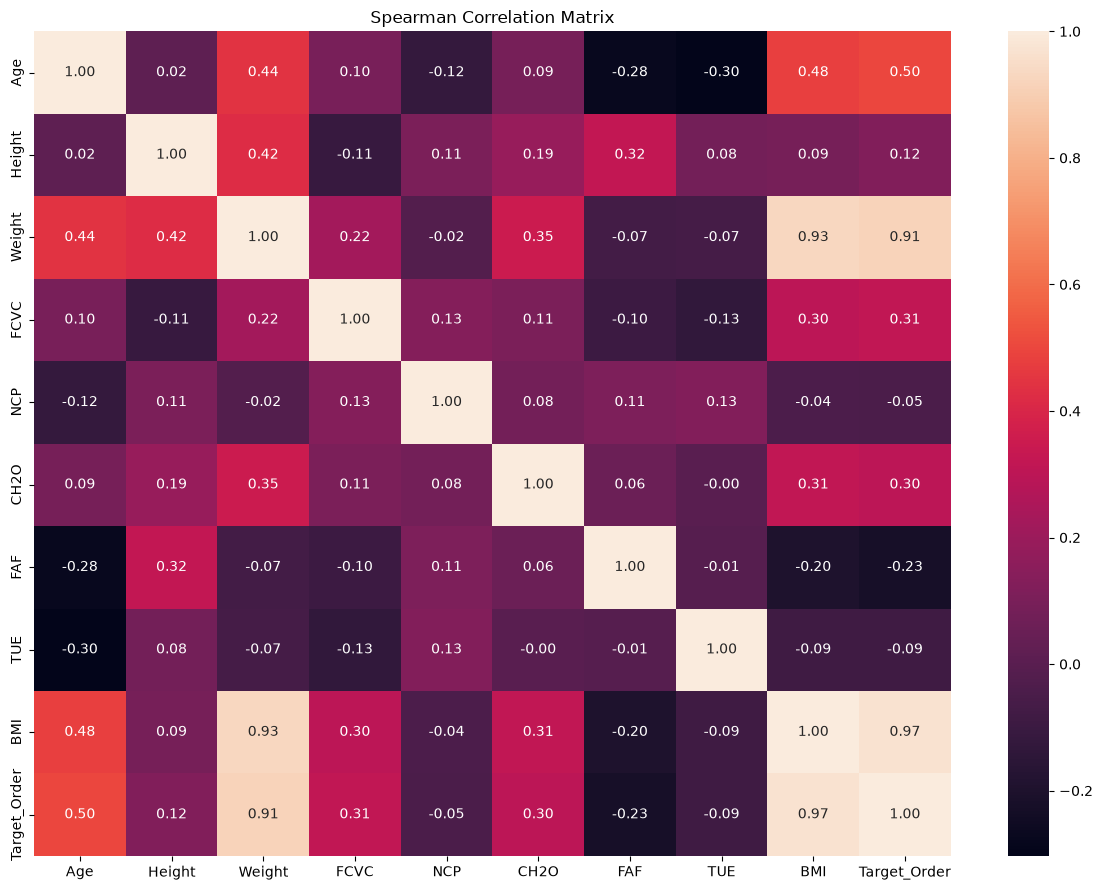

In [24]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

### Features Most Associated With Obesity-Risk Order

Extract each feature's Spearman correlation with `Target_Order` and arrange the results from strongest to weakest absolute relationship.

The absolute value is used for sorting because a strong negative relationship is also important.

A higher correlation shows a stronger association with the ordered target in this dataset. It does not directly measure a feature's importance in a trained machine learning model.

In [25]:
target_correlations = (
    spearman_correlation["Target_Order"]
    .drop("Target_Order")
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False,
    )
    .to_frame(name="Spearman correlation")
)

target_correlations

,Spearman correlation
BMI,0.967988
Weight,0.914899
Age,0.497429
FCVC,0.313013
CH2O,0.301579
FAF,-0.225321
Height,0.121465
TUE,-0.087855
NCP,-0.048091


## Key EDA Findings

The exploratory analysis provides the following observations about the obesity-risk dataset:

- **Class distribution:** The dataset contains seven obesity-risk categories with different numbers of records.

- **Numerical features:** Age, Height, Weight, and activity-related features show different distributions, ranges, and possible outliers.

- **Categorical features:** Some responses dominate their features, particularly `SMOKE` and `SCC`, while other features contain a wider variety of responses.

- **Physical measurements:** Height and Weight show a positive Pearson correlation (r = 0.417). Weight also varies across obesity-risk categories.

- **BMI:** Median BMI increases across the ordered obesity-risk categories, from 17.51 for Insufficient Weight to 41.75 for Obesity Type III.

- **Spearman correlation:** Calculated BMI (0.968) and Weight (0.915) show strong positive associations with the ordered obesity-risk categories.

- **Lifestyle features:** Eating habits, water consumption, physical activity, and other lifestyle features show different patterns across obesity-risk classes.

### Overall Interpretation

Physical measurements, particularly Weight and calculated BMI, show strong associations with obesity-risk categories in this dataset. Other numerical and categorical features also show differences between groups.

These findings help us understand the dataset, but correlation does not prove causation or directly determine which features a trained machine learning model will rely on most.

**Calculated BMI is used only for exploratory analysis. The original predictive dataset continues to contain 16 features.**